# About Dataset
This dataset contains retail sales transaction data designed for exploratory data analysis (EDA), SQL practice, and data analytics projects. It represents structured transactional records with key business attributes such as customers, products, pricing, quantities, and order dates.

The data has been cleaned to ensure consistency in formatting, data types, and categorical values, making it suitable for analysis without extensive pre-processing. It is ideal for beginners learning data analysis as well as analysts building portfolio projects

# 🛍️ TASK 1 — Exploratory Data Analysis on Retail Sales Data

### 👨‍💻 Prepared by: Ratnesh Chauhan

## 🎯 Objective

Perform a thorough Exploratory Data Analysis (EDA) on a retail sales
dataset to uncover sales patterns, customer behaviour, product trends,
and actionable business insights.

## 🛠️ Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 📌 Analysis Areas

1. Dataset inspection
2. Data quality checking
3. Descriptive statistics
4. Monthly sales analysis
5. Quarterly sales analysis
6. Customer age-group analysis
7. Gender analysis
8. Product category analysis
9. Correlation analysis
10. Additional business visualization
11. Business recommendations
12. Final conclusion

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Import seaborn for advanced statistical visualizations
import seaborn as sns

# Display charts directly inside Jupyter Notebook
%matplotlib inline

# Set a clean default style for charts
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the retail sales dataset
df = pd.read_csv("retail_sales_dataset.csv")

# Display the first 5 rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
# Check the number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1000
Number of Columns: 9


## 🔍 Initial Observation

The dataset contains **1,000 records and 9 columns**.

Each row represents a retail transaction containing information about
the transaction, customer, product category, quantity, price, and
total transaction amount.

# Dataset Information

In [4]:
# Display all column names
print("Column Names:")
for column in df.columns:
    print("-", column)

Column Names:
- Transaction ID
- Date
- Customer ID
- Gender
- Age
- Product Category
- Quantity
- Price per Unit
- Total Amount


# Check Missing Values

In [5]:
# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


# Missing Value Visualization

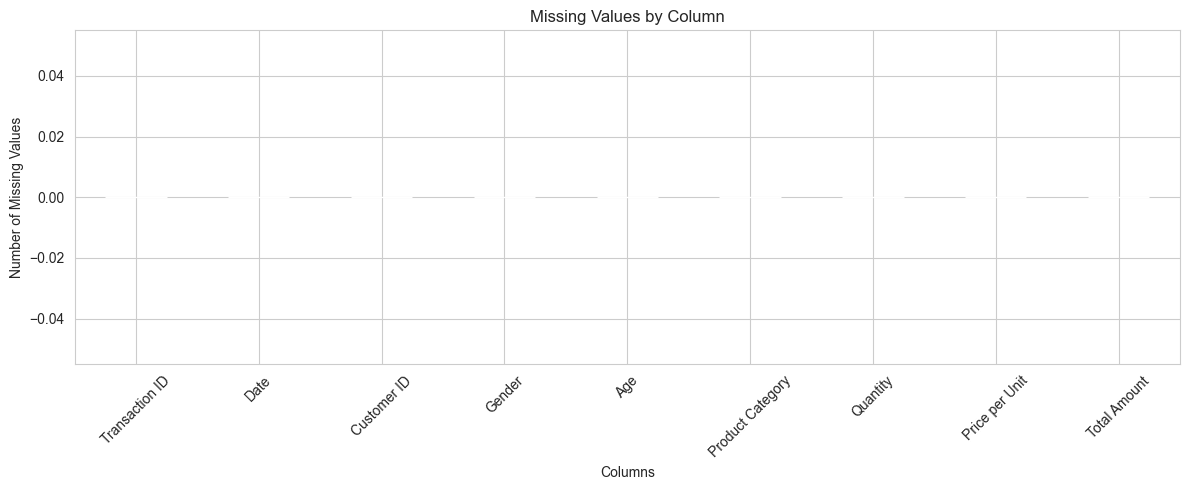

In [6]:
# Create a bar chart for missing values
plt.figure(figsize=(12, 5))

missing_values.plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📝 Observation — Missing Values

No missing values were found in any column.

Therefore, no missing-value imputation or row deletion is required.
The dataset is complete from a missing-value perspective.

# Check Duplicate Records

In [7]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


# Data Types

In [8]:
# Display the data type of every column
print(df.dtypes)

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


# Convert Date Column

In [9]:
# Convert the Date column from object/string format to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Check the updated data type
print(df["Date"].dtype)

datetime64[ns]


# Final Dataset Information

In [10]:
# Display the complete dataset information after converting Date
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [11]:
# Display the data type of every column
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


# Dataset Summary

In [12]:
# Create a basic summary of the dataset
summary = pd.DataFrame({
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Missing Values": [df.isnull().sum().sum()],
    "Duplicate Rows": [df.duplicated().sum()],
    "Unique Customers": [df["Customer ID"].nunique()],
    "Unique Transactions": [df["Transaction ID"].nunique()]
})

summary

,Rows,Columns,Missing Values,Duplicate Rows,Unique Customers,Unique Transactions
0,1000,9,0,0,1000,1000


# 📊 DESCRIPTIVE STATISTICS

# Numerical Columns

In [13]:
# Select all numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numerical_columns))

Numerical Columns:
['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']


# Mean

In [14]:
# Calculate the mean for all numerical columns
mean_values = df[numerical_columns].mean()

print("Mean:")
print(mean_values)

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


# Median

In [15]:
# Calculate the median for all numerical columns
median_values = df[numerical_columns].median()

print("Median:")
print(median_values)

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


# Mode

In [16]:
# Calculate the mode for all numerical columns
mode_values = df[numerical_columns].mode().iloc[0]

print("Mode:")
print(mode_values)

Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


# Standard Deviation

In [17]:
# Calculate standard deviation for all numerical columns
std_values = df[numerical_columns].std()

print("Standard Deviation:")
print(std_values)

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


# Complete Descriptive Statistics

In [18]:
# Create a custom descriptive statistics table
descriptive_statistics = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Standard Deviation": df[numerical_columns].std()
})

descriptive_statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


# Display standard descriptive statistics

In [19]:
# Display standard descriptive statistics
df[numerical_columns].describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


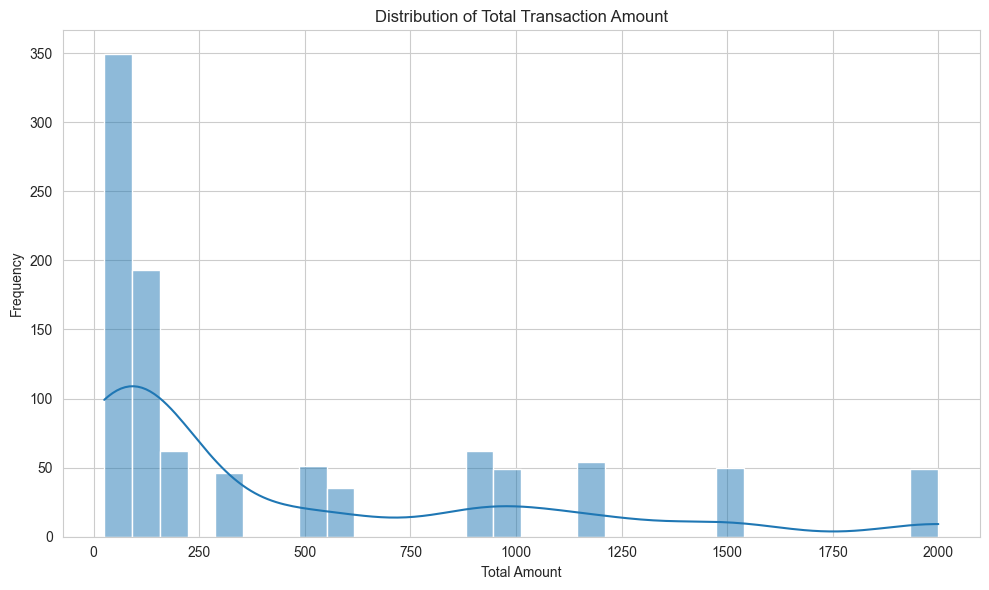

In [20]:
# Plot the distribution of transaction amount
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Total Amount"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Transaction Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 📝 Observation — Transaction Amount Distribution

The transaction amount distribution is right-skewed.

Most transactions have relatively lower values, while a smaller number
of transactions have considerably higher values.

This explains why the mean transaction amount is higher than the median.

# 📅 TIME SERIES ANALYSIS

In [21]:
# Extract year from Date
df["Year"] = df["Date"].dt.year

# Extract month number
df["Month"] = df["Date"].dt.month

# Extract month name
df["Month Name"] = df["Date"].dt.strftime("%B")

# Extract quarter
df["Quarter"] = df["Date"].dt.to_period("Q")

# Display new columns
df[["Date", "Year", "Month", "Month Name", "Quarter"]].head()

,Date,Year,Month,Month Name,Quarter
0,2023-11-24,2023,11,November,2023Q4
1,2023-02-27,2023,2,February,2023Q1
2,2023-01-13,2023,1,January,2023Q1
3,2023-05-21,2023,5,May,2023Q2
4,2023-05-06,2023,5,May,2023Q2


In [22]:
# Group sales by month
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Total Amount"]
    .sum()
)

# Display monthly sales
monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

# Monthly Sales Line Chart

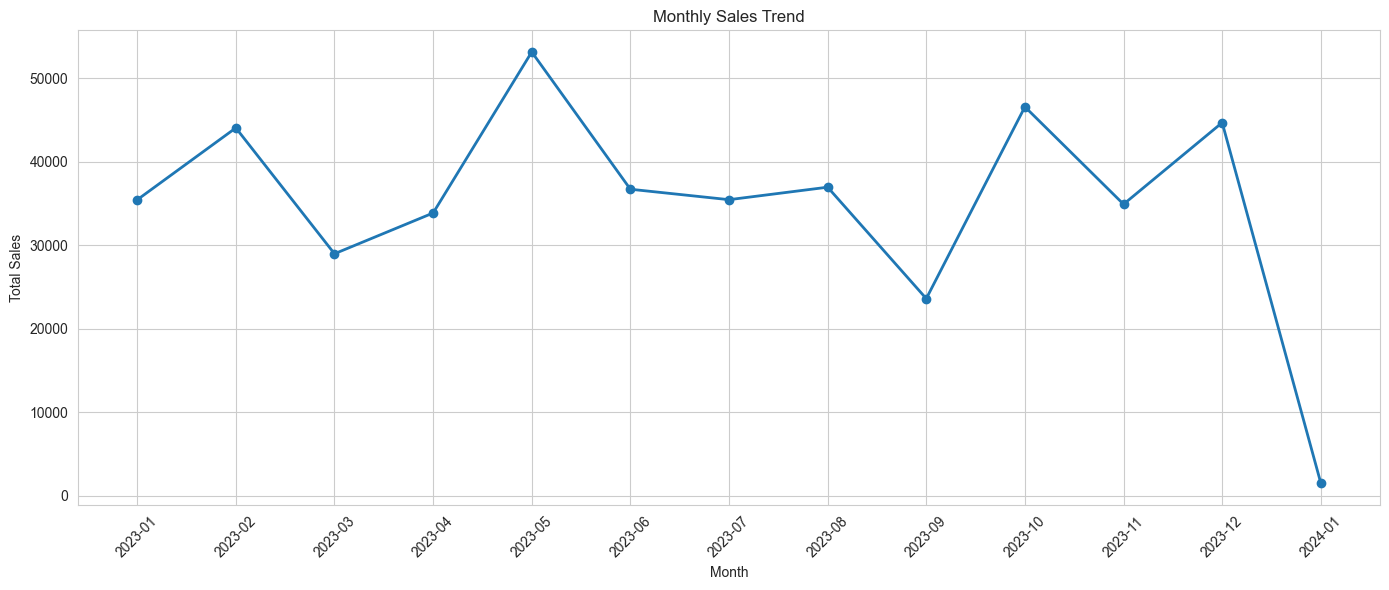

In [23]:
# Convert period values into strings for plotting
monthly_sales_plot = monthly_sales.copy()
monthly_sales_plot.index = monthly_sales_plot.index.astype(str)

# Create monthly sales line chart
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales_plot.index,
    monthly_sales_plot.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📝 Observation — Monthly Sales Trend

Monthly sales fluctuate throughout the year.

The highest complete-month revenue is observed in **May 2023**,
while **September 2023** records the lowest complete-month revenue.

January 2024 contains only one day of data, so it should not be directly
compared with complete months.

In [24]:
# Find the month with the highest sales
highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

# Find the month with the lowest sales
lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", highest_month_sales)

print("\nLowest Sales Month:", lowest_month)
print("Lowest Sales:", lowest_month_sales)

Highest Sales Month: 2023-05
Highest Sales: 53150

Lowest Sales Month: 2024-01
Lowest Sales: 1530


In [25]:
# Group total sales by quarter
quarterly_sales = (
    df.groupby(df["Date"].dt.to_period("Q"))["Total Amount"]
    .sum()
)

print(quarterly_sales)

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


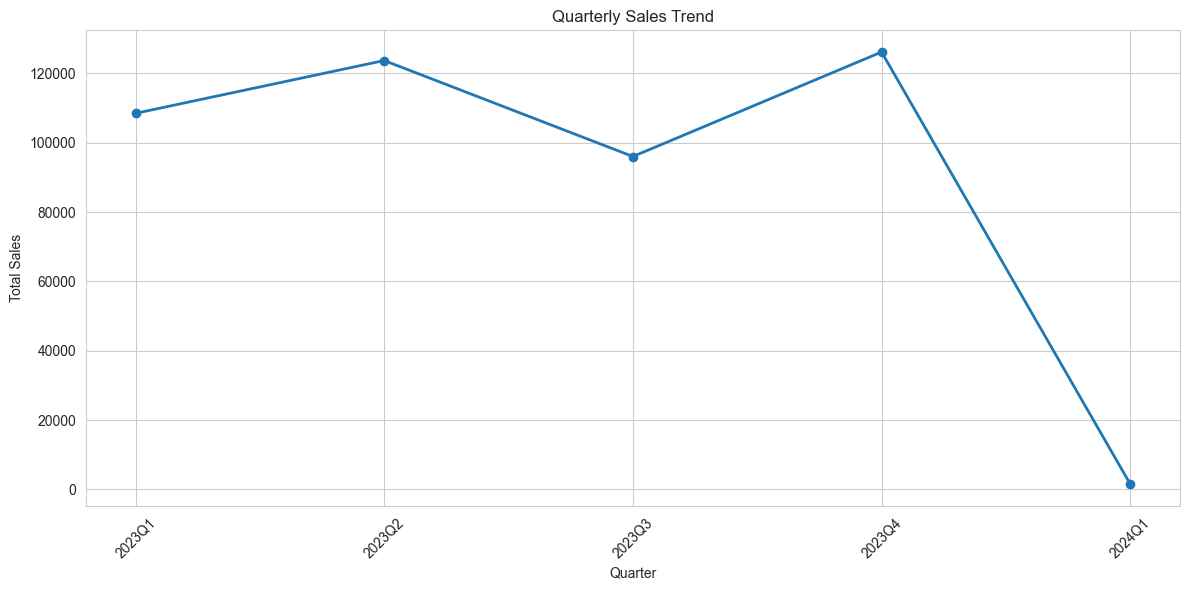

In [26]:
# Convert quarter values to strings
quarterly_sales_plot = quarterly_sales.copy()
quarterly_sales_plot.index = quarterly_sales_plot.index.astype(str)

# Create quarterly sales line chart
plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales_plot.index,
    quarterly_sales_plot.values,
    marker="o",
    linewidth=2
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📝 Observation — Quarterly Sales Trend

Among the complete quarters of 2023, **Q4 2023** generated the highest
revenue.

Q3 2023 recorded the lowest revenue among the four complete quarters.

The strong Q4 performance suggests that seasonal demand, promotions,
or year-end purchasing may have influenced sales.

# 👥 CUSTOMER DEMOGRAPHICS

In [27]:
# Display basic statistics for customer age
df["Age"].describe()

count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64

In [28]:
# Define age-group boundaries
age_bins = [17, 25, 35, 45, 55, 65]

# Define age-group labels
age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65"
]

# Create Age Group column
df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

# Count customers in each age group
age_group_counts = df["Age Group"].value_counts().sort_index()

age_group_counts

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-65    195
Name: count, dtype: int64

## Create age-group bar chart

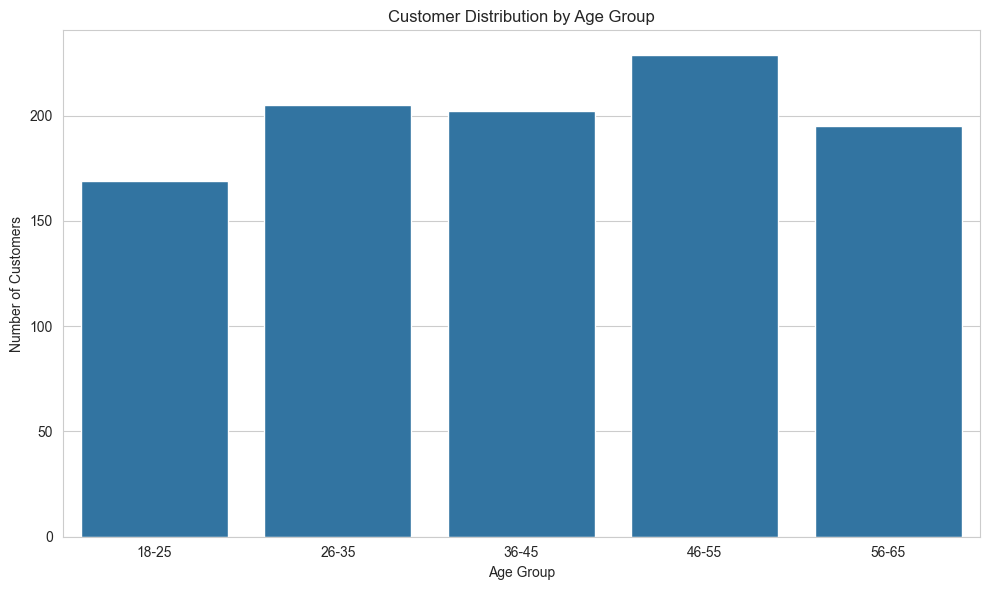

In [29]:
# Create age-group bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 📝 Observation — Quarterly Sales Trend

Among the complete quarters of 2023, **Q4 2023** generated the highest
revenue.

Q3 2023 recorded the lowest revenue among the four complete quarters.

The strong Q4 performance suggests that seasonal demand, promotions,
or year-end purchasing may have influenced sales.

# 👥 CUSTOMER DEMOGRAPHICS

In [30]:
# Display basic statistics for customer age
df["Age"].describe()

count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64

In [31]:
# Define age-group boundaries
age_bins = [17, 25, 35, 45, 55, 65]

# Define age-group labels
age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65"
]

# Create Age Group column
df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

# Count customers in each age group
age_group_counts = df["Age Group"].value_counts().sort_index()

age_group_counts

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-65    195
Name: count, dtype: int64

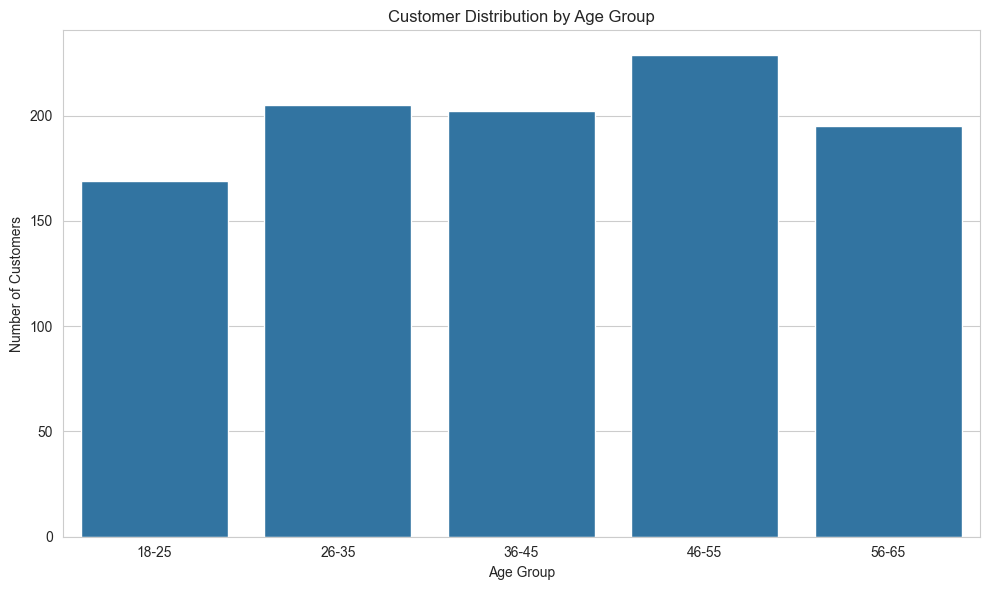

In [32]:
# Create age-group bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 📝 Observation — Age Group Distribution

The **46–55 age group** represents the largest customer segment.

The dataset also shows strong participation from customers aged 26–45
and 56–65.

Therefore, marketing should not focus only on younger customers.

In [33]:
# Count customers by gender
gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
Female    510
Male      490
Name: count, dtype: int64


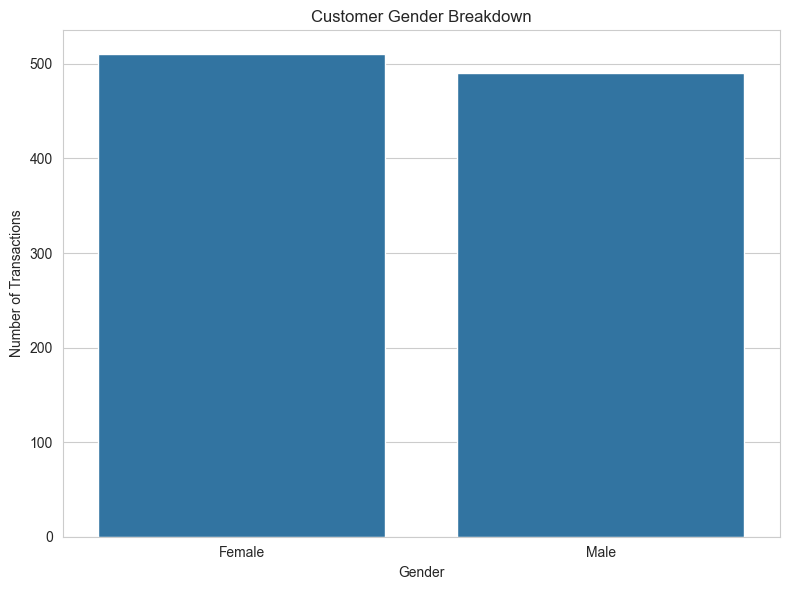

In [34]:
# Create gender distribution chart
plt.figure(figsize=(8, 6))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [35]:
# Calculate total revenue generated by each gender
gender_revenue = (
    df.groupby("Gender")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

gender_revenue

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

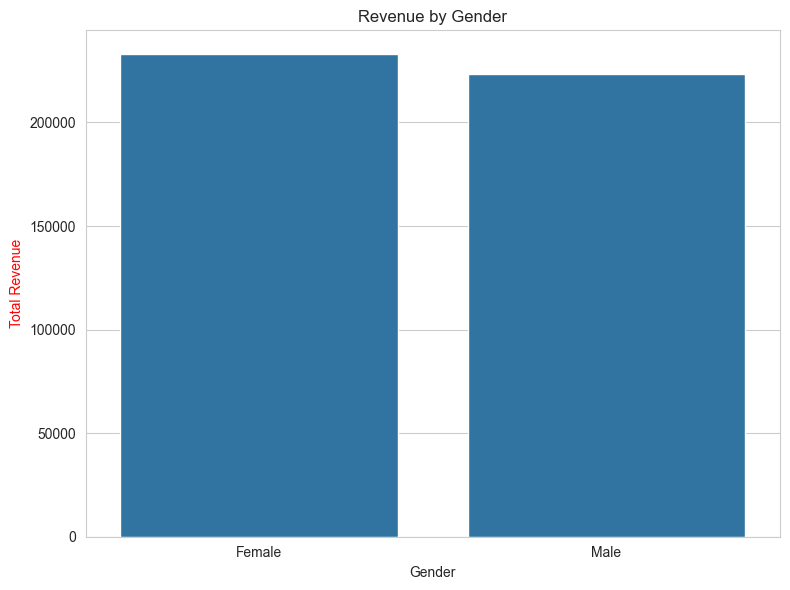

In [37]:
# Plot revenue by gender
plt.figure(figsize=(8, 6))

sns.barplot(
    x=gender_revenue.index,
    y=gender_revenue.values
)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue",color="Red")
plt.tight_layout()
plt.show()

## 📝 Observation — Revenue by Gender

Female customers generate slightly more total revenue than male customers.

However, the difference is relatively small.

The higher female revenue is mainly related to the slightly higher number
of female transactions rather than a major difference in average spending.

# 🛍️ PRODUCT ANALYSIS

In [38]:
# Count transactions for each product category
category_counts = (
    df["Product Category"]
    .value_counts()
)

category_counts

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [39]:
# Calculate total quantity sold for each category
category_quantity = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

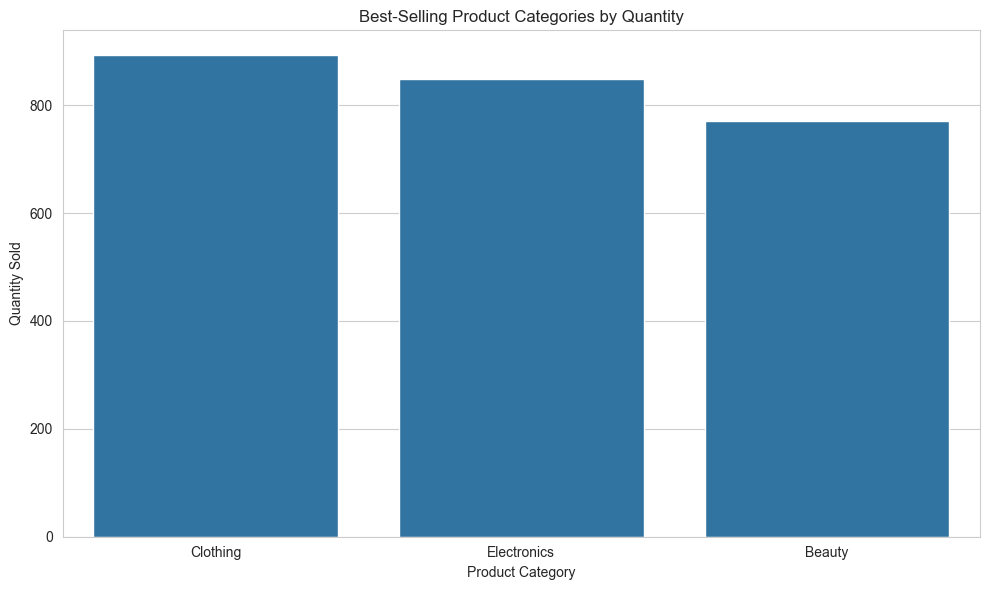

In [40]:
# Plot quantity sold by product category
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values
)

plt.title("Best-Selling Product Categories by Quantity")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.show()

## 📝 Observation — Best-Selling Categories

Clothing has the highest sales volume with the largest quantity sold.

Electronics ranks second, while Beauty has the lowest quantity among
the three categories.

Because the dataset does not contain individual product names or product
IDs, category-level analysis is used instead of a Top 10 Product analysis.

In [41]:
# Calculate revenue for each product category
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

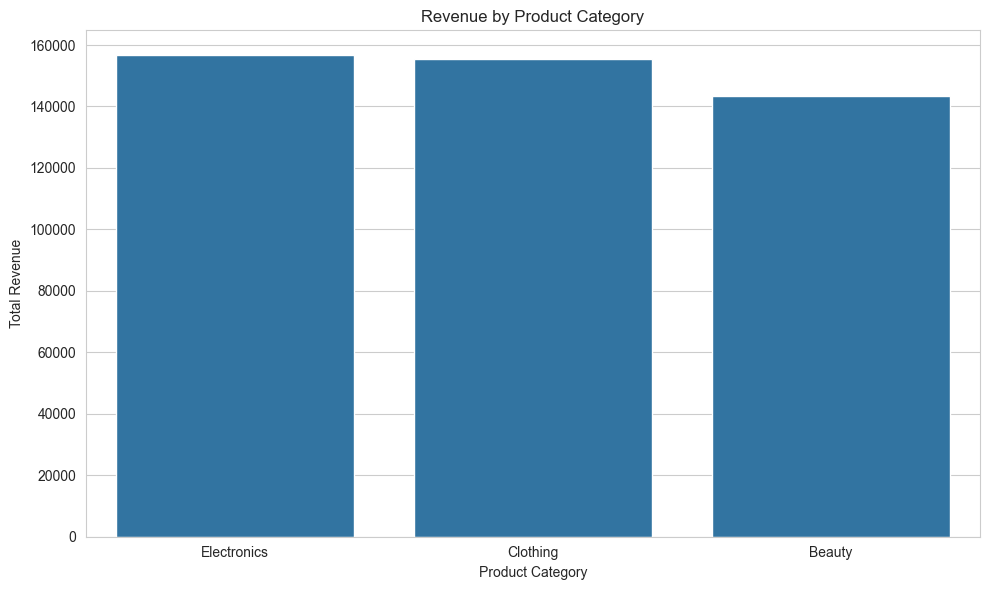

## 📝 Observation — Revenue by Product Category

Electronics generates the highest total revenue, even though Clothing
has a higher quantity sold.

This is an important business insight:

**The category with the highest sales volume is not necessarily the
category with the highest revenue.**

Electronics likely benefits from higher prices per unit.

In [43]:
# Create a combined product-category performance table
category_analysis = df.groupby("Product Category").agg(
    Transactions=("Transaction ID", "count"),
    Quantity_Sold=("Quantity", "sum"),
    Revenue=("Total Amount", "sum"),
    Average_Transaction=("Total Amount", "mean")
).sort_values("Revenue", ascending=False)

category_analysis

,Transactions,Quantity_Sold,Revenue,Average_Transaction
Product Category,,,,
Electronics,342,849,156905,458.786550
Clothing,351,894,155580,443.247863
Beauty,307,771,143515,467.475570


In [44]:
# Check whether an individual product column exists
product_columns = [
    column for column in df.columns
    if "product" in column.lower()
]

print("Product-related columns:")
print(product_columns)

Product-related columns:
['Product Category']


## ⚠️ Top 10 Product Analysis — Dataset Limitation

The dataset contains only **Product Category** and does not contain
individual product names, product IDs, or SKUs.

Therefore, a genuine Top 10 Product analysis cannot be performed without
inventing information that is not present in the dataset.

Instead, the analysis focuses on the best-selling product categories.

# 🔥 CORRELATION ANALYSIS

In [45]:
# Select numerical columns for correlation analysis
correlation_columns = [
    "Transaction ID",
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

# Calculate correlation matrix
correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


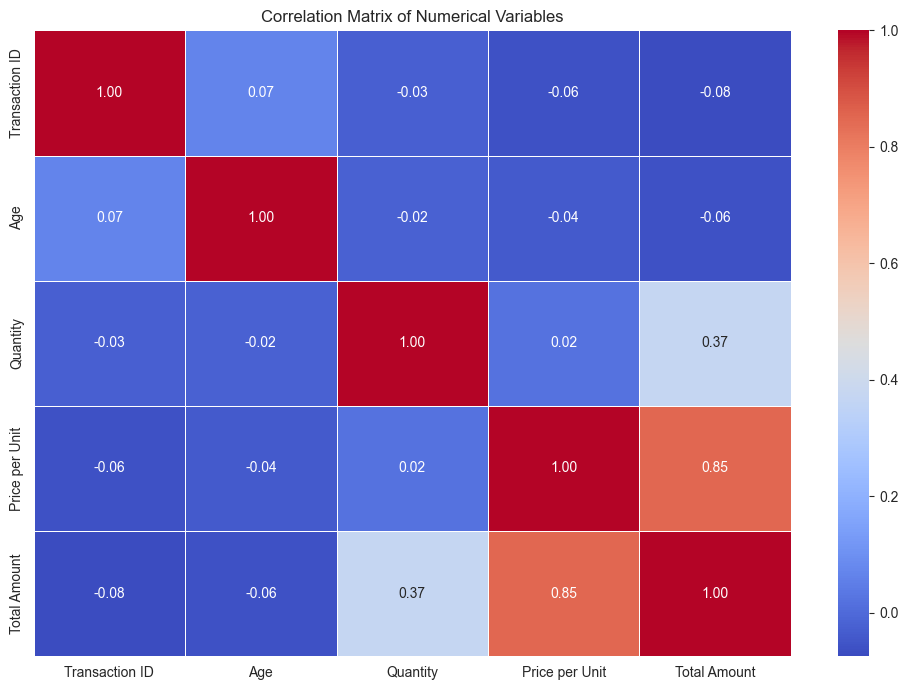

In [46]:
# Create correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 📝 Observation — Correlation Heatmap

The strongest relationship is expected between **Quantity**, **Price per
Unit**, and **Total Amount**, because transaction amount is calculated
from quantity and unit price.

Age has a comparatively weaker relationship with transaction amount.

Correlation shows the strength of a statistical relationship, but it
does not prove causation.

# 🔎 ADDITIONAL VISUALIZATION

In [52]:
# Calculate average transaction amount for each age group
age_group_spending = (
    df.groupby("Age Group", observed=True)["Total Amount"]
    .mean()
)

age_group_spending

Age Group
18-25    500.295858
26-35    480.390244
36-45    454.801980
46-55    439.694323
56-65    412.358974
Name: Total Amount, dtype: float64

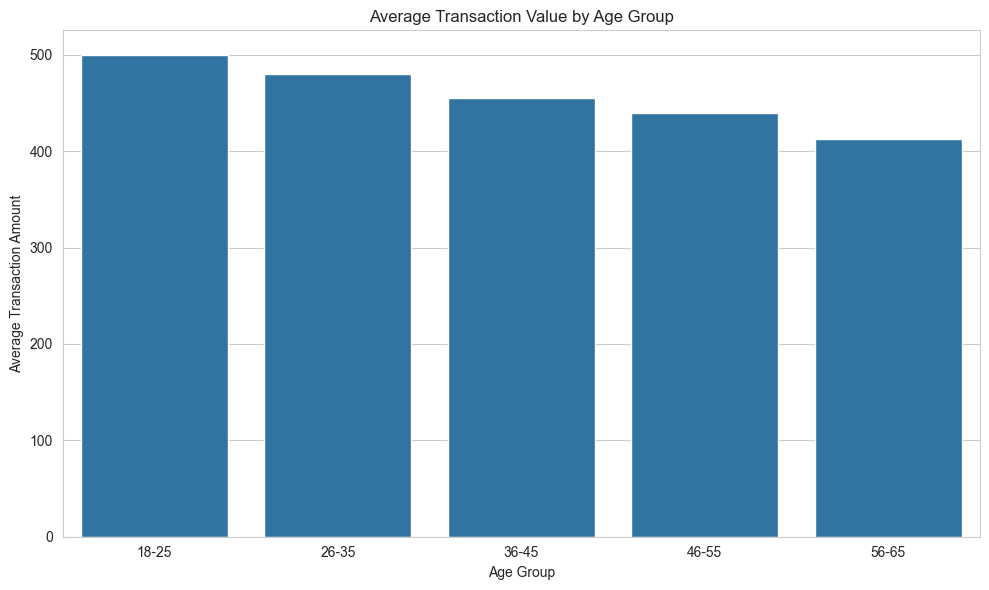

In [53]:
# Plot average transaction value by age group
plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_group_spending.index,
    y=age_group_spending.values
)

plt.title("Average Transaction Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")
plt.tight_layout()
plt.show()

## 📝 Observation — Average Spending by Age Group

The number of customers in an age group does not necessarily indicate
how much each customer spends per transaction.

Comparing average transaction values helps identify whether certain age
segments have stronger purchasing value even when their customer count
is lower.

This provides an additional customer-segmentation insight beyond simply
counting customers.

In [54]:
# Calculate average transaction value by gender
gender_average_transaction = (
    df.groupby("Gender")["Total Amount"]
    .mean()
    .sort_values(ascending=False)
)

gender_average_transaction

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

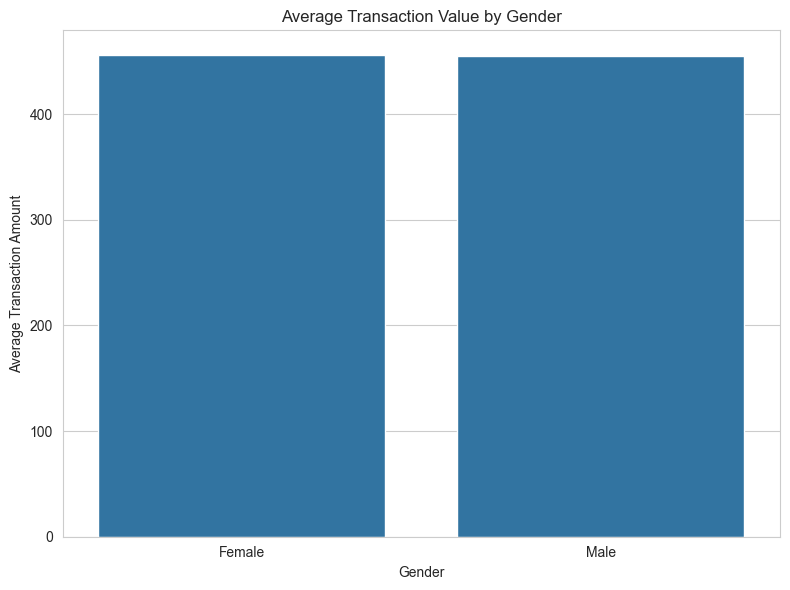

In [55]:
# Plot average transaction value by gender
plt.figure(figsize=(8, 6))

sns.barplot(
    x=gender_average_transaction.index,
    y=gender_average_transaction.values
)

plt.title("Average Transaction Value by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Transaction Amount")
plt.tight_layout()
plt.show()

In [56]:
# Compare quantity sold and revenue by category
category_comparison = df.groupby("Product Category").agg(
    Quantity=("Quantity", "sum"),
    Revenue=("Total Amount", "sum")
)

category_comparison

,Quantity,Revenue
Product Category,,
Beauty,771,143515
Clothing,894,155580
Electronics,849,156905


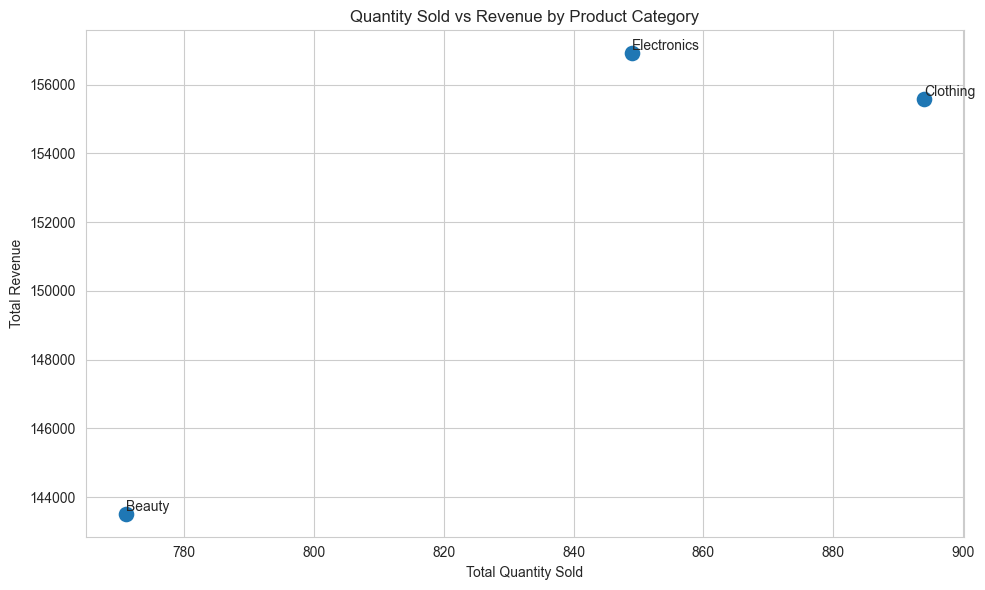

In [57]:
# Create a scatter plot to compare quantity and revenue
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=category_comparison,
    x="Quantity",
    y="Revenue",
    s=150
)

# Add category labels
for category, row in category_comparison.iterrows():
    plt.text(
        row["Quantity"],
        row["Revenue"],
        category,
        fontsize=10,
        ha="left",
        va="bottom"
    )

plt.title("Quantity Sold vs Revenue by Product Category")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## 📝 Observation — Quantity vs Revenue

Clothing has the highest quantity sold, but Electronics produces the
highest revenue.

This confirms that sales volume alone is not sufficient to evaluate
category performance.

Revenue and average selling price should also be considered when making
product decisions.

In [58]:
# Calculate average price per unit for each category
average_price_category = (
    df.groupby("Product Category")["Price per Unit"]
    .mean()
    .sort_values(ascending=False)
)

average_price_category

Product Category
Beauty         184.055375
Electronics    181.900585
Clothing       174.287749
Name: Price per Unit, dtype: float64

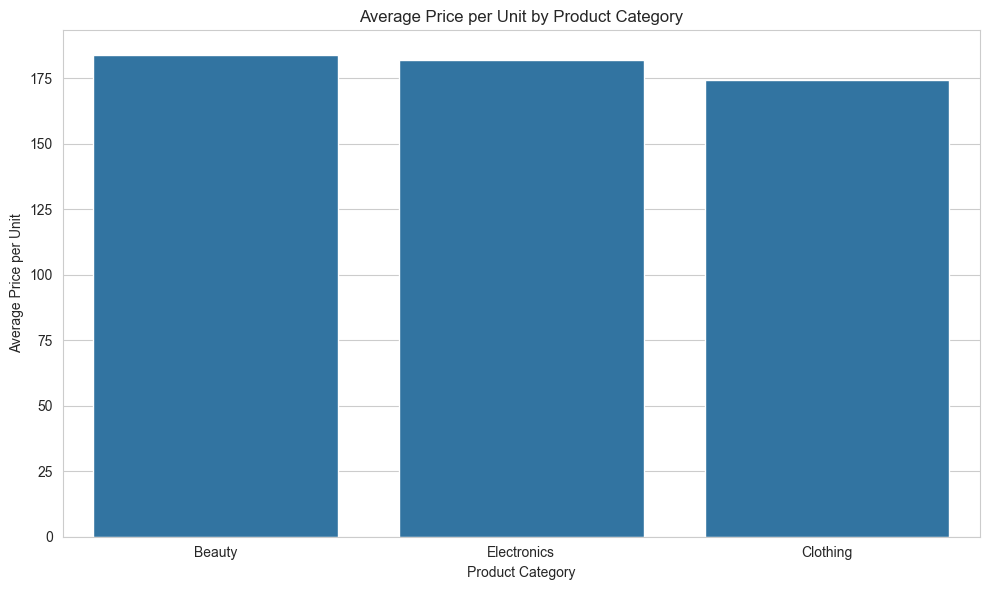

In [59]:
# Plot average price per unit by category
plt.figure(figsize=(10, 6))

sns.barplot(
    x=average_price_category.index,
    y=average_price_category.values
)

plt.title("Average Price per Unit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Price per Unit")
plt.tight_layout()
plt.show()

## 📝 Observation — Average Price per Unit

Differences in average unit price help explain why Electronics can
generate the highest revenue even though Clothing has the highest
quantity sold.

Therefore, both **sales volume and pricing strategy** should be
considered when evaluating product categories.

In [60]:
# Calculate total revenue
total_revenue = df["Total Amount"].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹456,000.00


In [61]:
# Calculate average transaction value
average_transaction = df["Total Amount"].mean()

print(f"Average Transaction Value: ₹{average_transaction:,.2f}")

Average Transaction Value: ₹456.00


In [62]:
# Calculate total quantity sold
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 2514


In [63]:
# Create a KPI summary
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Transactions",
        "Total Revenue",
        "Total Quantity Sold",
        "Average Transaction Value",
        "Average Customer Age",
        "Unique Customers"
    ],
    "Value": [
        df["Transaction ID"].nunique(),
        df["Total Amount"].sum(),
        df["Quantity"].sum(),
        df["Total Amount"].mean(),
        df["Age"].mean(),
        df["Customer ID"].nunique()
    ]
})

kpi_summary

,KPI,Value
0,Total Transactions,1000.000
1,Total Revenue,456000.000
2,Total Quantity Sold,2514.000
3,Average Transaction Value,456.000
4,Average Customer Age,41.392
5,Unique Customers,1000.000


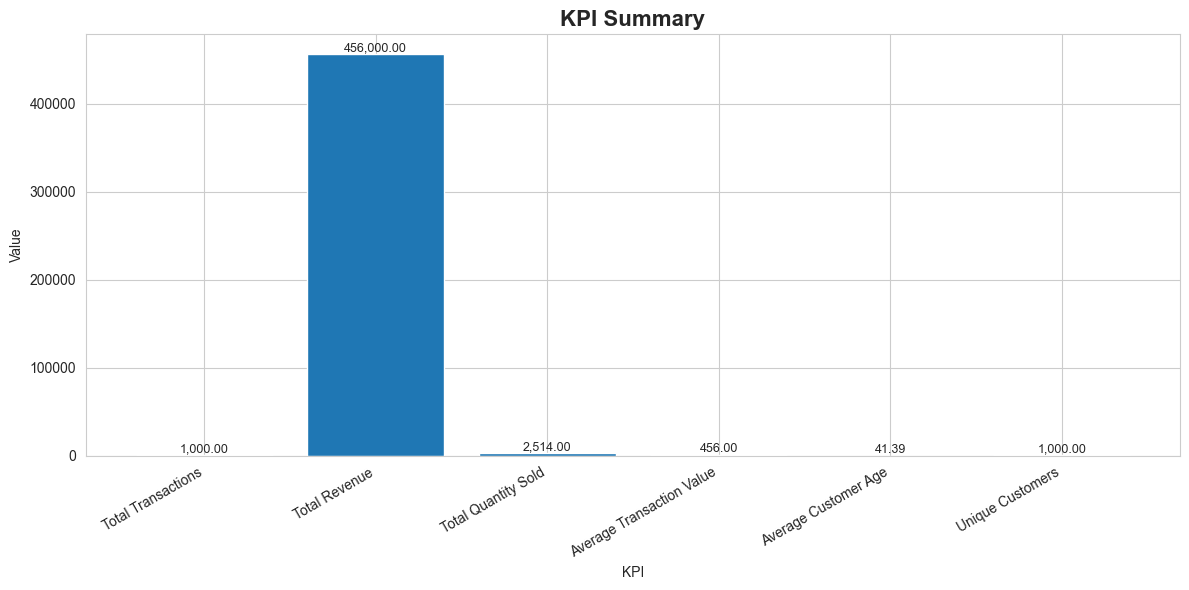

In [66]:

# Convert KPI values into a DataFrame
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Transactions",
        "Total Revenue",
        "Total Quantity Sold",
        "Average Transaction Value",
        "Average Customer Age",
        "Unique Customers"
    ],
    "Value": [
        df["Transaction ID"].nunique(),
        df["Total Amount"].sum(),
        df["Quantity"].sum(),
        df["Total Amount"].mean(),
        df["Age"].mean(),
        df["Customer ID"].nunique()
    ]
})

# Create KPI bar graph
plt.figure(figsize=(12, 6))

plt.bar(kpi_summary["KPI"], kpi_summary["Value"])

plt.title("KPI Summary", fontsize=16, fontweight="bold")
plt.xlabel("KPI")
plt.ylabel("Value")

plt.xticks(rotation=30, ha="right")

# Add values on top of bars
for i, value in enumerate(kpi_summary["Value"]):
    plt.text(i, value, f"{value:,.2f}", 
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# 🎯 FINAL BUSINESS INSIGHTS

In [64]:
# Identify important business insights automatically

best_month = monthly_sales.idxmax()
best_month_value = monthly_sales.max()

best_quarter = quarterly_sales.idxmax()
best_quarter_value = quarterly_sales.max()

best_quantity_category = category_quantity.idxmax()
best_quantity_value = category_quantity.max()

best_revenue_category = category_revenue.idxmax()
best_revenue_value = category_revenue.max()

largest_age_group = age_group_counts.idxmax()
largest_age_group_count = age_group_counts.max()

print("========== KEY BUSINESS INSIGHTS ==========")

print(f"Total Revenue: ₹{total_revenue:,.2f}")

print(
    f"Highest Revenue Month: {best_month} "
    f"with ₹{best_month_value:,.2f}"
)

print(
    f"Highest Revenue Quarter: {best_quarter} "
    f"with ₹{best_quarter_value:,.2f}"
)

print(
    f"Highest Quantity Category: {best_quantity_category} "
    f"with {best_quantity_value} units"
)

print(
    f"Highest Revenue Category: {best_revenue_category} "
    f"with ₹{best_revenue_value:,.2f}"
)

print(
    f"Largest Age Group: {largest_age_group} "
    f"with {largest_age_group_count} customers"
)

========== KEY BUSINESS INSIGHTS ==========
Total Revenue: ₹456,000.00
Highest Revenue Month: 2023-05 with ₹53,150.00
Highest Revenue Quarter: 2023Q4 with ₹126,190.00
Highest Quantity Category: Clothing with 894 units
Highest Revenue Category: Electronics with ₹156,905.00
Largest Age Group: 46-55 with 229 customers


# 📝 FINAL CONCLUSION

# 🏆 Conclusion — Exploratory Data Analysis

## 📌 1. Dataset Quality

The retail sales dataset contains **1,000 transactions and 9 columns**.
No missing values and no duplicate records were found.

The dataset is therefore clean and suitable for exploratory analysis.

---

## 📊 2. Sales Performance

The total revenue generated is approximately **₹4.56 lakh**.

Monthly sales fluctuate throughout the year, with **May 2023** recording
the highest complete-month revenue.

Among the complete quarters of 2023, **Q4 2023** generated the highest
revenue.

---

## 👥 3. Customer Demographics

The customer base is almost evenly distributed between male and female
customers.

The **46–55 age group** represents the largest customer segment.

This suggests that the business should consider middle-aged customers as
an important target market rather than focusing only on younger customers.

---

## 🛍️ 4. Product Performance

**Clothing** has the highest quantity sold and the highest number of
transactions.

However, **Electronics** generates the highest revenue.

This demonstrates that the category with the highest sales volume is not
necessarily the category with the highest revenue.

---

## 💡 5. Customer Spending

Average transaction values for male and female customers are very similar.

Therefore, the slightly higher female revenue is mainly associated with
the slightly higher number of female transactions.

---

# 🚀 Actionable Business Recommendations

### 1. Focus on Electronics

Electronics generates the highest revenue.

The business should investigate successful electronics products and use
bundling, cross-selling, and promotional strategies to increase revenue.

### 2. Improve Clothing Monetization

Clothing has the highest sales volume but does not generate the highest
revenue.

The business can increase clothing revenue through premium products,
bundles, upselling, and cross-selling.

### 3. Investigate Low-Sales Periods

September 2023 recorded relatively low sales.

The company should investigate customer demand, inventory, pricing, and
marketing activity during this period.

### 4. Target the 46–55 Age Group

The 46–55 age group represents the largest customer segment.

Targeted marketing campaigns and suitable product offers can be
developed for this customer group.

### 5. Use Seasonal Sales Insights

Q4 2023 performed strongly.

The business should prepare inventory and marketing campaigns before
high-performing periods and identify the factors responsible for strong
seasonal performance.

---

## ⚠️ Dataset Limitation

The dataset contains **Product Category**, but it does not contain
individual product names, product IDs, or SKUs.

Therefore, a genuine **Top 10 Best-Selling Products** analysis cannot be
performed from this dataset without making unsupported assumptions.

Category-level product analysis was used instead.

---

## 🎯 Final Takeaway

The EDA shows that sales performance depends on multiple factors,
including **product category, pricing, transaction volume, customer
demographics, and seasonality**.

The most important finding is that **Clothing leads in sales volume,
while Electronics leads in revenue**.

This distinction can help management make better decisions about
pricing, inventory, promotions, and customer targeting.

In [65]:
# Final dataset validation

print("========== FINAL DATA VALIDATION ==========")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDate Range:")
print("Start Date:", df["Date"].min().date())
print("End Date:", df["Date"].max().date())

print("\nTotal Revenue:")
print(f"₹{df['Total Amount'].sum():,.2f}")

print("\nTotal Quantity Sold:")
print(df["Quantity"].sum())

print("\nUnique Customers:")
print(df["Customer ID"].nunique())

print("\nAnalysis completed successfully.")

========== FINAL DATA VALIDATION ==========
Dataset Shape: (1000, 14)

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Year                0
Month               0
Month Name          0
Quarter             0
Age Group           0
dtype: int64

Duplicate Rows: 0

Date Range:
Start Date: 2023-01-01
End Date: 2024-01-01

Total Revenue:
₹456,000.00

Total Quantity Sold:
2514

Unique Customers:
1000

Analysis completed successfully.
